In [1]:
import sys, os
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:", repo_root)
from fixedincomelib import *
print("Fixed Income Library is loaded.")

Added to sys.path: e:\FRE 9743\FRE-GT-9743-Assignment-5
Fixed Income Library is loaded.


# Instructions for HW5:

## PCA implementation

### 1. Write PCA algorithm

Please implement a PCA algorithm without using existing PCA api, which means you're only allowed to use Numpy package.

In [2]:
class PCA:
    """
    Principal Component Analysis (PCA) implementation using only NumPy.
    
    This class performs PCA by:
    1. Centering the data (subtract mean)
    2. Computing the covariance matrix
    3. Computing eigenvalues and eigenvectors
    4. Sorting components by explained variance
    5. Transforming data to principal component space
    """
    
    def __init__(self, n_components: Optional[int] = None):
        """
        Initialize PCA.
        
        Parameters:
        -----------
        n_components : int, optional
            Number of principal components to keep.
            If None, keep all components.
        """
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None  # Principal components (eigenvectors)
        self.eigenvalues_ = None  # Eigenvalues
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        
    def fit(self, X: np.ndarray):
        """
        Fit the PCA model with X.
        
        Parameters:
        -----------
        X : np.ndarray of shape (n_samples, n_features)
            Training data
            
        Returns:
        --------
        self : object
        """
        # Step 1: Center the data (subtract mean)
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        
        # Step 2: Compute covariance matrix
        # Cov = (X_centered.T @ X_centered) / (n_samples - 1)
        n_samples = X.shape[0]
        cov_matrix = (X_centered.T @ X_centered) / (n_samples - 1)
        
        # Step 3: Compute eigenvalues and eigenvectors using eigh
        # Use eigh (not eig) because covariance matrix is symmetric
        # eigh is faster, more stable, and guarantees real eigenvalues
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        # Step 4: Sort eigenvalues and eigenvectors in descending order
        # eigh returns eigenvalues in ascending order, so we reverse
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        
        # CRITICAL: Save total variance BEFORE truncation
        # This ensures explained_variance_ratio_ is relative to TOTAL variance, not truncated variance
        total_variance = np.sum(eigenvalues)
        
        # Step 5: Select the top n_components
        if self.n_components is not None:
            eigenvalues = eigenvalues[:self.n_components]
            eigenvectors = eigenvectors[:, :self.n_components]
        
        # Store results
        # No need for .real since eigh guarantees real outputs for symmetric matrices
        self.eigenvalues_ = eigenvalues
        self.components_ = eigenvectors.T  # Shape: (n_components, n_features)
        self.explained_variance_ = self.eigenvalues_
        
        # Calculate explained variance ratio using TOTAL variance (not truncated)
        self.explained_variance_ratio_ = self.eigenvalues_ / total_variance
        
        return self
    
    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Apply dimensionality reduction to X.
        
        Parameters:
        -----------
        X : np.ndarray of shape (n_samples, n_features)
            Data to transform
            
        Returns:
        --------
        X_transformed : np.ndarray of shape (n_samples, n_components)
            Transformed data
        """
        # Center the data using the mean from training data
        X_centered = X - self.mean_
        
        # Project onto principal components
        # X_transformed = X_centered @ components.T
        X_transformed = X_centered @ self.components_.T
        
        return X_transformed
    
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        """
        Fit the model with X and apply dimensionality reduction.
        
        Parameters:
        -----------
        X : np.ndarray of shape (n_samples, n_features)
            Training data
            
        Returns:
        --------
        X_transformed : np.ndarray of shape (n_samples, n_components)
            Transformed data
        """
        self.fit(X)
        return self.transform(X)
    
    def inverse_transform(self, X_transformed: np.ndarray) -> np.ndarray:
        """
        Transform data back to original space.
        
        Parameters:
        -----------
        X_transformed : np.ndarray of shape (n_samples, n_components)
            Transformed data
            
        Returns:
        --------
        X_original : np.ndarray of shape (n_samples, n_features)
            Data in original space
        """
        # Project back: X_original = X_transformed @ components + mean
        X_reconstructed = X_transformed @ self.components_ + self.mean_
        
        return X_reconstructed
    
    def get_covariance(self):
        """
        Compute data covariance with the generative model.
        
        Returns:
        --------
        cov : np.ndarray of shape (n_features, n_features)
            Estimated covariance of data
        """
        # Cov = components.T @ diag(explained_variance) @ components
        cov = self.components_.T @ np.diag(self.explained_variance_) @ self.components_
        return cov

print("PCA class implemented successfully!")

PCA class implemented successfully!


### 2. Apply PCA

Please download fixed-floating swap rate data from Bloomberg (Ticker: YCSW0490) covering at least six months, with the sample period ending on 2026-02-26.

Although you should download the data for 2026-02-27, exclude that date from the PCA analysis.

The swap tenors should range from 1Y to 30Y.

The dataset should be organized in the format shown below.

After preparing the dataset, apply Principal Component Analysis (PCA) as discussed in class.

![Chart](data_sample.png)

In [3]:
# Load the swap rate data
data_path = os.path.join(repo_root, "data.csv")
df = pd.read_csv(data_path, index_col=0)

# Exclude 2/27/2026 (row 0) as instructed
df = df.iloc[1:].copy()

# Convert date column to datetime
df['Dates'] = pd.to_datetime(df['Dates'])

# Sort by date (oldest to newest)
df = df.sort_values('Dates').reset_index(drop=True)

print(f"Data shape: {df.shape}")
print(f"Date range: {df['Dates'].min()} to {df['Dates'].max()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nLast few rows:")
print(df.tail())

# Extract tenor columns (all except 'Dates')
tenor_columns = [col for col in df.columns if col != 'Dates']
print(f"\nTenors: {tenor_columns}")

# Prepare data matrix for PCA (rows = dates, columns = tenors)
X = df[tenor_columns].values
print(f"\nData matrix shape: {X.shape}")
print(f"Number of observations: {X.shape[0]}")
print(f"Number of tenors: {X.shape[1]}")


Data shape: (130, 16)
Date range: 2025-08-31 00:00:00 to 2026-02-26 00:00:00

First few rows:
       Dates     12M      2Y      3Y      4Y      5Y      6Y      7Y      8Y  \
0 2025-08-31  3.7515  3.3908  3.2940  3.2945  3.3350  3.4003  3.4749  3.5497   
1 2025-09-01  3.7630  3.3908  3.2940  3.2945  3.3350  3.4003  3.4749  3.5497   
2 2025-09-02  3.7601  3.4141  3.3193  3.3170  3.3560  3.4218  3.4980  3.5733   
3 2025-09-03  3.7344  3.3910  3.2965  3.2937  3.3311  3.3936  3.4662  3.5388   
4 2025-09-04  3.7020  3.3546  3.2565  3.2493  3.2829  3.3433  3.4141  3.4865   

       9Y     10Y     12Y     15Y     20Y     25Y     30Y  
0  3.6217  3.6910  3.8185  3.9622  4.0832  4.1065  4.0844  
1  3.6217  3.6910  3.8185  3.9622  4.0832  4.1065  4.0844  
2  3.6463  3.7165  3.8448  3.9903  4.1122  4.1359  4.1139  
3  3.6097  3.6778  3.8022  3.9428  4.0593  4.0799  4.0553  
4  3.5570  3.6253  3.7506  3.8939  4.0143  4.0375  4.0151  

Last few rows:
         Dates     12M      2Y      3Y      4Y   

In [4]:
# Apply PCA to the swap rate data
print("Applying PCA to swap rate data...")
pca_full = PCA(n_components=None)  # Keep all components
X_transformed = pca_full.fit_transform(X)

# Define reusable variables for analysis and visualization
explained_pct = pca_full.explained_variance_ratio_ * 100
cumulative_pct = np.cumsum(explained_pct)
pc_labels = ['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)']
pc_scores = X_transformed[:, :3]

print(f"\nPCA Results:")
print(f"Number of components: {len(pca_full.eigenvalues_)}")
print(f"\nFirst 3 Principal Components:")
print(f"  PC1: {explained_pct[0]:.2f}% | PC2: {explained_pct[1]:.2f}% | PC3: {explained_pct[2]:.2f}%")
print(f"  Cumulative: {cumulative_pct[2]:.2f}%")
print(f"\n(Detailed results in Summary Table below)")


Applying PCA to swap rate data...

PCA Results:
Number of components: 15

First 3 Principal Components:
  PC1: 91.65% | PC2: 6.03% | PC3: 2.24%
  Cumulative: 99.92%

(Detailed results in Summary Table below)


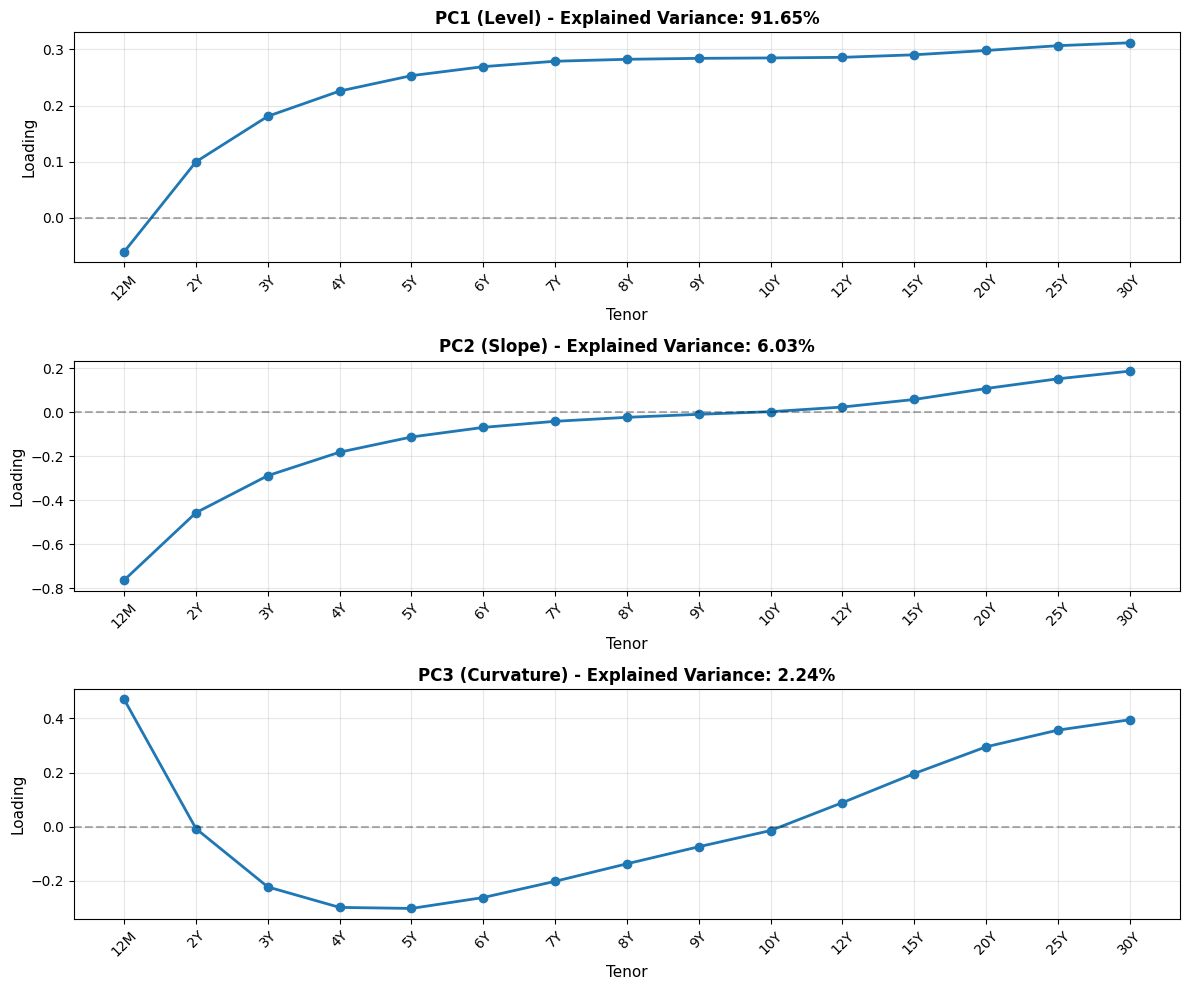

✓ Principal components visualized!


In [5]:
# Visualize the principal components (eigenvectors)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot first 3 principal components
for i in range(3):
    axes[i].plot(tenor_columns, pca_full.components_[i], 'o-', linewidth=2, markersize=6)
    axes[i].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[i].set_xlabel('Tenor', fontsize=11)
    axes[i].set_ylabel('Loading', fontsize=11)
    axes[i].set_title(f'{pc_labels[i]} - Explained Variance: {explained_pct[i]:.2f}%', 
                     fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✓ Principal components visualized!")


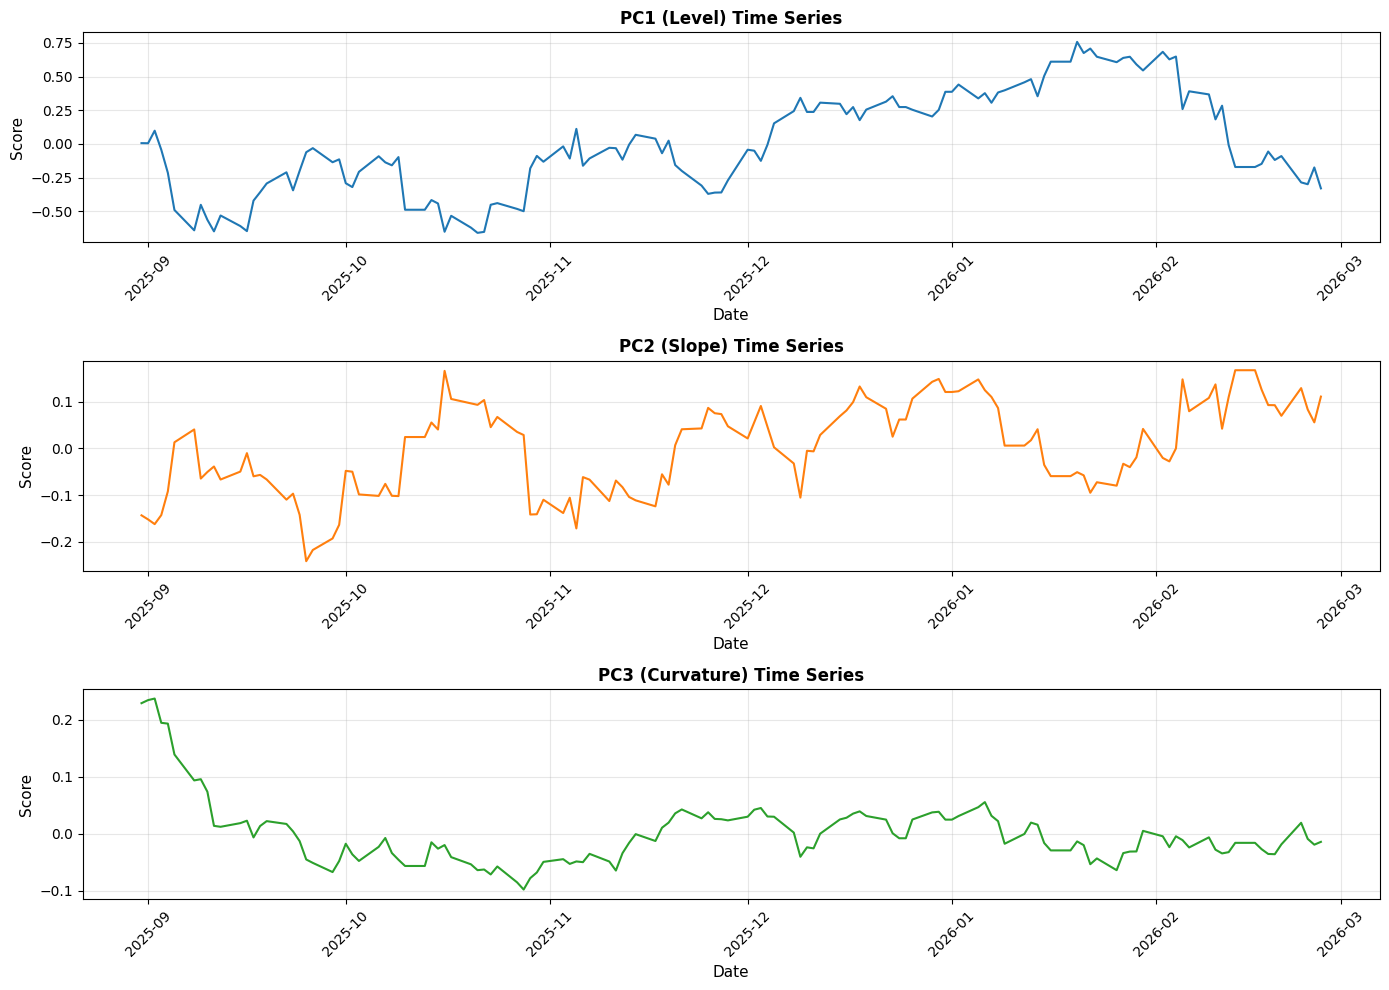

✓ Principal component scores over time visualized!


In [6]:
# Analyze the time series of principal component scores
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

dates = df['Dates'].values

for i in range(3):
    axes[i].plot(dates, pc_scores[:, i], linewidth=1.5, color=f'C{i}')
    axes[i].set_xlabel('Date', fontsize=11)
    axes[i].set_ylabel('Score', fontsize=11)
    axes[i].set_title(f'{pc_labels[i]} Time Series', fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✓ Principal component scores over time visualized!")


In [7]:
# Create a summary table of the principal components
pc_summary = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(pca_full.eigenvalues_))],
    'Eigenvalue': pca_full.eigenvalues_,
    'Variance Explained (%)': explained_pct,
    'Cumulative Variance (%)': cumulative_pct
})

print("Principal Component Analysis Summary:")
print(pc_summary.head(10))

# Create a loadings table for the first 3 PCs
loadings_df = pd.DataFrame(
    pca_full.components_[:3].T,
    columns=pc_labels,
    index=tenor_columns
)

print("\n\nPrincipal Component Loadings (First 3 PCs):")
print(loadings_df)


Principal Component Analysis Summary:
  Component    Eigenvalue  Variance Explained (%)  Cumulative Variance (%)
0       PC1  1.401268e-01               91.653071                91.653071
1       PC2  9.219415e-03                6.030165                97.683236
2       PC3  3.417372e-03                2.235209                99.918445
3       PC4  8.273794e-05                0.054117                99.972562
4       PC5  3.209167e-05                0.020990                99.993552
5       PC6  6.742785e-06                0.004410                99.997962
6       PC7  2.186410e-06                0.001430                99.999392
7       PC8  3.577662e-07                0.000234                99.999626
8       PC9  1.912979e-07                0.000125                99.999752
9      PC10  1.608726e-07                0.000105                99.999857


Principal Component Loadings (First 3 PCs):
     PC1 (Level)  PC2 (Slope)  PC3 (Curvature)
12M    -0.060884    -0.762995         0.4700

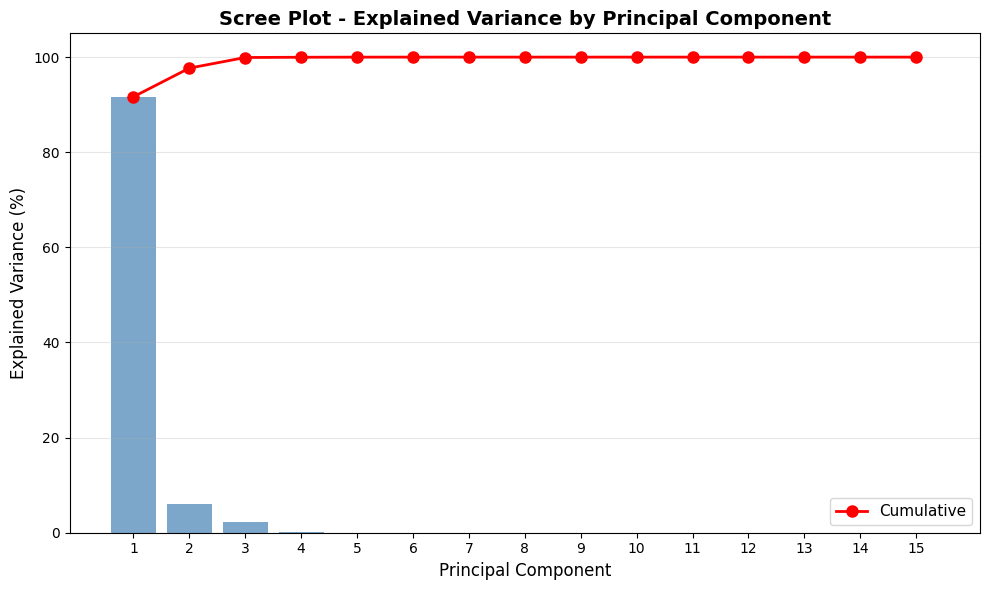


✓ Question 2 Complete!

Key Findings:
- PC1 explains 91.65% of variance (Level factor)
- PC2 explains 6.03% of variance (Slope factor)
- PC3 explains 2.24% of variance (Curvature factor)
- First 3 PCs explain 99.92% of total variance


In [8]:
# Scree plot - visualize explained variance by component
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

components = np.arange(1, len(pca_full.eigenvalues_) + 1)
ax.bar(components, explained_pct, alpha=0.7, color='steelblue')
ax.plot(components, cumulative_pct, 
        'ro-', linewidth=2, markersize=8, label='Cumulative')
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Explained Variance (%)', fontsize=12)
ax.set_title('Scree Plot - Explained Variance by Principal Component', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(components)

plt.tight_layout()
plt.show()

print(f"\n✓ Question 2 Complete!")
print(f"\nKey Findings:")
print(f"- PC1 explains {explained_pct[0]:.2f}% of variance (Level factor)")
print(f"- PC2 explains {explained_pct[1]:.2f}% of variance (Slope factor)")
print(f"- PC3 explains {explained_pct[2]:.2f}% of variance (Curvature factor)")
print(f"- First 3 PCs explain {cumulative_pct[2]:.2f}% of total variance")


### 3. Hedging with PCA

With your PCA results, please try to reconstruct the risk profile provided, and present your results.

In [9]:
# read risk_agg.csv
risk_agg = pd.read_csv(os.path.join(repo_root,"risk_agg.csv"))
print("Risk Aggregation Data:")
risk_agg.head()

Risk Aggregation Data:


,Unnamed: 0,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
0,AGG_RISK,2.982972,-1.857554,0.013279,0.071185,13.975129,-5.458591,-0.025772,-7.003277,0.043624,12.783767,-15.256859,-21.13873,-17.444482,0.0,0.0


Risk Profile (DV01 by Tenor):
  Unnamed: 0        1Y        2Y        3Y        4Y         5Y        6Y  \
0   AGG_RISK  2.982972 -1.857554  0.013279  0.071185  13.975129 -5.458591   

         7Y        8Y        9Y        10Y        12Y       15Y        20Y  \
0 -0.025772 -7.003277  0.043624  12.783767 -15.256859 -21.13873 -17.444482   

   25Y  30Y  
0  0.0  0.0  

Risk vector shape: (15,)
Risk tenors: ['1Y' '2Y' '3Y' '4Y' '5Y' '6Y' '7Y' '8Y' '9Y' '10Y' '12Y' '15Y' '20Y'
 '25Y' '30Y']

Risk DV01 values:
[ 2.98297187e+00 -1.85755448e+00  1.32791298e-02  7.11852838e-02
  1.39751286e+01 -5.45859119e+00 -2.57717119e-02 -7.00327709e+00
  4.36237494e-02  1.27837665e+01 -1.52568589e+01 -2.11387298e+01
 -1.74444823e+01  0.00000000e+00  0.00000000e+00]


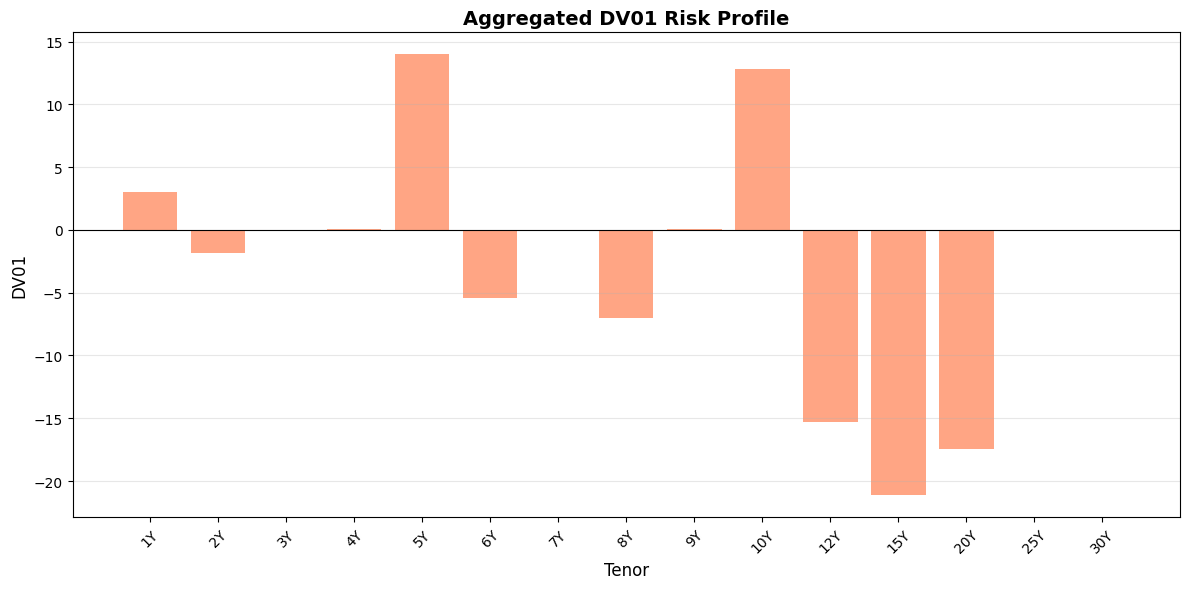


✓ Risk profile loaded and visualized!


In [10]:
# Examine the risk aggregation data
print("Risk Profile (DV01 by Tenor):")
print(risk_agg)

# Extract the risk vector
# Assuming the risk_agg has tenors as columns or a specific structure
if 'Tenor' in risk_agg.columns:
    # If data is in long format
    risk_vector = risk_agg.set_index('Tenor')['DV01'].values.astype(float)
    risk_tenors = risk_agg['Tenor'].values
else:
    # If data is in wide format (first column is label, rest are values)
    risk_tenors = risk_agg.columns[1:].values
    risk_vector = risk_agg.iloc[0, 1:].values.astype(float)

print(f"\nRisk vector shape: {risk_vector.shape}")
print(f"Risk tenors: {risk_tenors}")
print(f"\nRisk DV01 values:")
print(risk_vector)

# Visualize the risk profile
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.bar(range(len(risk_vector)), risk_vector, alpha=0.7, color='coral')
ax.set_xlabel('Tenor', fontsize=12)
ax.set_ylabel('DV01', fontsize=12)
ax.set_title('Aggregated DV01 Risk Profile', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(risk_vector)))
ax.set_xticklabels(risk_tenors, rotation=45)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n✓ Risk profile loaded and visualized!")

Using the provided hedging instruments, solve for the optimal portfolio weights that hedge the aggregated DV01 risk profile. 

Compare the eigenspace approach against direct least squares, and argue mathematically why the former is preferred.

In [11]:
hedging = pd.read_csv(os.path.join(repo_root,"hedging_instruments.csv"))
print("Hedging Instruments Data:")
hedging.head()

Hedging Instruments Data:


,Unnamed: 0,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,12Y,15Y,20Y,25Y,30Y
0,1Y1Y,0.990383,-1.905780,-0.040437,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,1Y5Y,0.986415,0.006578,0.000573,0.001714,0.049129,-5.468511,-0.035436,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2,5Y5Y,0.002970,0.005982,0.009149,0.012336,4.626952,-0.016352,-0.019360,-0.022309,-0.025584,-8.501197,0.000000,0.000000,0.000000,0.0,0.0
3,10Y10Y,0.003699,0.007465,0.011399,0.015366,0.019642,0.023980,0.028543,0.032885,0.037736,8.499983,-0.093768,-0.198309,-14.335121,0.0,0.0


Hedging Instruments Profile:
  Unnamed: 0        1Y        2Y        3Y        4Y        5Y        6Y  \
0       1Y1Y  0.990383 -1.905780 -0.040437  0.000000  0.000000  0.000000   
1       1Y5Y  0.986415  0.006578  0.000573  0.001714  0.049129 -5.468511   
2       5Y5Y  0.002970  0.005982  0.009149  0.012336  4.626952 -0.016352   
3     10Y10Y  0.003699  0.007465  0.011399  0.015366  0.019642  0.023980   

         7Y        8Y        9Y       10Y       12Y       15Y        20Y  25Y  \
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   0.000000  0.0   
1 -0.035436  0.000000  0.000000  0.000000  0.000000  0.000000   0.000000  0.0   
2 -0.019360 -0.022309 -0.025584 -8.501197  0.000000  0.000000   0.000000  0.0   
3  0.028543  0.032885  0.037736  8.499983 -0.093768 -0.198309 -14.335121  0.0   

   30Y  
0  0.0  
1  0.0  
2  0.0  
3  0.0  

Hedging matrix shape: (4, 15)
Number of hedging instruments: 4
Instruments: ['1Y1Y' '1Y5Y' '5Y5Y' '10Y10Y']


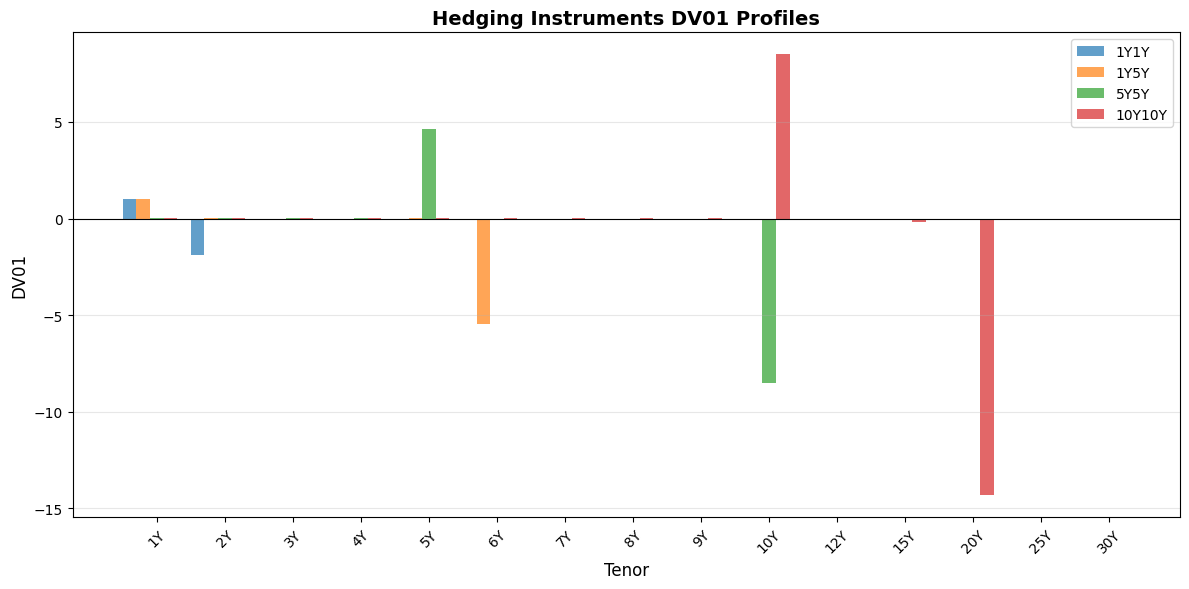


✓ Hedging instruments loaded and visualized!


In [12]:
# Examine the hedging instruments data
print("Hedging Instruments Profile:")
print(hedging)

# Extract hedging instruments matrix
# Each row should be a hedging instrument with DV01s across tenors
if 'Instrument' in hedging.columns or 'Name' in hedging.columns:
    instrument_col = 'Instrument' if 'Instrument' in hedging.columns else 'Name'
    instrument_names = hedging[instrument_col].values
    hedging_matrix = hedging.drop(columns=[instrument_col]).values.astype(float)
else:
    # First column is instrument names, rest are DV01 values
    instrument_names = hedging.iloc[:, 0].values
    hedging_matrix = hedging.iloc[:, 1:].values.astype(float)

print(f"\nHedging matrix shape: {hedging_matrix.shape}")
print(f"Number of hedging instruments: {len(instrument_names)}")
print(f"Instruments: {instrument_names}")

# Visualize the hedging instruments
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
x_pos = np.arange(hedging_matrix.shape[1])
width = 0.8 / len(instrument_names)

for i, name in enumerate(instrument_names):
    offset = (i - len(instrument_names)/2) * width
    ax.bar(x_pos + offset, hedging_matrix[i], width, label=name, alpha=0.7)

ax.set_xlabel('Tenor', fontsize=12)
ax.set_ylabel('DV01', fontsize=12)
ax.set_title('Hedging Instruments DV01 Profiles', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(risk_tenors, rotation=45)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n✓ Hedging instruments loaded and visualized!")


### Verify Tenor Space Alignment

Before performing any tenor-space operations (projection, hedging), we must verify that all three data sources (PCA, Risk, Hedging) are defined in the same tenor space with consistent ordering.

In [13]:
# CRITICAL: Verify tenor space alignment across all three data sources
print("="*80)
print("TENOR SPACE ALIGNMENT VERIFICATION")
print("="*80)

# 1. PCA tenors (from Question 2)
# Standardize tenor naming: '12M' -> '1Y' for consistency
pca_tenors = list(tenor_columns)
pca_tenors_standardized = ['1Y' if t == '12M' else t for t in pca_tenors]
print("\n1. PCA Tenors (used for covariance matrix):")
print(f"   Count: {len(pca_tenors_standardized)}")
print(f"   Tenors: {pca_tenors_standardized}")

# 2. Risk tenors (from risk_agg.csv)
print("\n2. Risk Tenors (from risk_agg.csv):")
print(f"   Count: {len(risk_tenors)}")
print(f"   Tenors: {list(risk_tenors)}")

# 3. Hedging instrument tenors (from hedging_instruments.csv)
hedge_tenors_from_data = hedging.columns[1:].tolist()  # Skip first column (instrument names)
print("\n3. Hedge Instrument Tenors (from hedging_instruments.csv):")
print(f"   Count: {len(hedge_tenors_from_data)}")
print(f"   Tenors: {hedge_tenors_from_data}")

# Alignment checks
print("\n" + "="*80)
print("ALIGNMENT CHECK RESULTS")
print("="*80)

# Convert all to lists for proper comparison
risk_tenors_list = [str(t) for t in risk_tenors]
hedge_tenors_list = [str(t) for t in hedge_tenors_from_data]

pca_risk_match = (pca_tenors_standardized == risk_tenors_list)
pca_hedge_match = (pca_tenors_standardized == hedge_tenors_list)
risk_hedge_match = (risk_tenors_list == hedge_tenors_list)

print(f"\n✓ PCA ≡ Risk Tenors:    {pca_risk_match}")
print(f"✓ PCA ≡ Hedge Tenors:   {pca_hedge_match}")
print(f"✓ Risk ≡ Hedge Tenors:  {risk_hedge_match}")

if pca_risk_match and pca_hedge_match:
    print("\n VERIFICATION PASSED: All tenor spaces are perfectly aligned!")
    print("   Safe to proceed with projection and hedging operations.")
else:
    print("\n WARNING: Tenor misalignment detected!")
    print("   This will cause incorrect results in projection and optimization.")
    print("   Action required: Reorder or filter tenors before proceeding.")

print("\n" + "="*80)

TENOR SPACE ALIGNMENT VERIFICATION

1. PCA Tenors (used for covariance matrix):
   Count: 15
   Tenors: ['1Y', '2Y', '3Y', '4Y', '5Y', '6Y', '7Y', '8Y', '9Y', '10Y', '12Y', '15Y', '20Y', '25Y', '30Y']

2. Risk Tenors (from risk_agg.csv):
   Count: 15
   Tenors: ['1Y', '2Y', '3Y', '4Y', '5Y', '6Y', '7Y', '8Y', '9Y', '10Y', '12Y', '15Y', '20Y', '25Y', '30Y']

3. Hedge Instrument Tenors (from hedging_instruments.csv):
   Count: 15
   Tenors: ['1Y', '2Y', '3Y', '4Y', '5Y', '6Y', '7Y', '8Y', '9Y', '10Y', '12Y', '15Y', '20Y', '25Y', '30Y']

ALIGNMENT CHECK RESULTS

✓ PCA ≡ Risk Tenors:    True
✓ PCA ≡ Hedge Tenors:   True
✓ Risk ≡ Hedge Tenors:  True

 VERIFICATION PASSED: All tenor spaces are perfectly aligned!
   Safe to proceed with projection and hedging operations.



### Method 1: Eigenspace Approach (PCA-based Hedging)

The eigenspace approach works as follows:
1. Use the principal components (eigenvectors) from PCA as a basis
2. Project the risk profile onto the PC space
3. Project hedging instruments onto the PC space  
4. Solve for weights in the lower-dimensional PC space
5. This focuses on hedging the most important risk factors

In [14]:
# Method 1: Eigenspace Approach (PCA-based hedging)
# Use the first 3 principal components from our PCA analysis

n_pcs = 3  # Use first 3 PCs (explaining 99.92% of variance)
PC_basis = pca_full.components_[:n_pcs, :]  # Shape: (3, 15)

print("Eigenspace Approach:")
print(f"Using first {n_pcs} principal components")
print(f"PC basis shape: {PC_basis.shape}")

# Project risk vector onto PC space
risk_pc = risk_vector @ PC_basis.T  # Shape: (3,)
print(f"\nRisk profile in PC space:")
for i in range(n_pcs):
    print(f"  PC{i+1}: {risk_pc[i]:.6f}")

# Project hedging instruments onto PC space
hedging_pc = hedging_matrix @ PC_basis.T  # Shape: (n_instruments, 3)
print(f"\nHedging instruments in PC space:")
print(f"Shape: {hedging_pc.shape}")
print(hedging_pc)

# Solve for optimal weights in PC space to minimize || hedging_pc.T @ w - risk_pc ||^2
# This is a least squares problem: hedging_pc.T @ w ≈ risk_pc
# Solution: w = (hedging_pc @ hedging_pc.T)^(-1) @ hedging_pc @ risk_pc

hedging_pc_T = hedging_pc.T  # Shape: (3, n_instruments)
weights_eigenspace = np.linalg.lstsq(hedging_pc_T, risk_pc, rcond=None)[0]

print(f"\n✓ Optimal weights (Eigenspace approach):")
for i, (name, weight) in enumerate(zip(instrument_names, weights_eigenspace)):
    print(f"  {name}: {weight:.6f}")

# Calculate the hedged risk profile in original space
hedged_risk_eigenspace = hedging_matrix.T @ weights_eigenspace
residual_risk_eigenspace = risk_vector - hedged_risk_eigenspace

# Cache metrics to avoid repeated calculations
risk_norm = np.linalg.norm(risk_vector)
resid_norm_eig = np.linalg.norm(residual_risk_eigenspace)
effectiveness_eig = (1 - resid_norm_eig/risk_norm) * 100

print(f"\nHedging Performance (Eigenspace):")
print(f"  Original risk L2 norm: {risk_norm:.6f}")
print(f"  Residual risk L2 norm: {resid_norm_eig:.6f}")
print(f"  Hedge effectiveness: {effectiveness_eig:.4f}%")

Eigenspace Approach:
Using first 3 principal components
PC basis shape: (3, 15)

Risk profile in PC space:
  PC1: -12.314667
  PC2: -5.894150
  PC3: -11.275225

Hedging instruments in PC space:
Shape: (4, 3)
[[-0.25751438  0.12643624  0.48805981]
 [-1.52922491 -0.3812251   1.88379748]
 [-1.26836978 -0.54739061 -1.26744013]
 [-1.89177733 -1.55357744 -4.42705041]]

✓ Optimal weights (Eigenspace approach):
  1Y1Y: 2.553171
  1Y5Y: 1.308287
  5Y5Y: 4.475625
  10Y10Y: 2.103723

Hedging Performance (Eigenspace):
  Original risk L2 norm: 37.866279
  Residual risk L2 norm: 44.847991
  Hedge effectiveness: -18.4378%


### Method 2: Direct Least Squares Approach

The direct approach:
1. Solve directly in the original tenor space
2. Minimize || H^T w - r ||^2 where H is hedging matrix, r is risk vector
3. Uses all 15 dimensions without dimension reduction

In [15]:
# Method 2: Direct Least Squares Approach
# Solve directly in the original tenor space

print("Direct Least Squares Approach:")
print(f"Solving in original {hedging_matrix.shape[1]}-dimensional space")

# Solve for optimal weights: minimize || hedging_matrix.T @ w - risk_vector ||^2
# Solution: w = (H @ H.T)^(-1) @ H @ r
weights_direct = np.linalg.lstsq(hedging_matrix.T, risk_vector, rcond=None)[0]

print(f"\n✓ Optimal weights (Direct LS approach):")
for i, (name, weight) in enumerate(zip(instrument_names, weights_direct)):
    print(f"  {name}: {weight:.6f}")

# Calculate the hedged risk profile
hedged_risk_direct = hedging_matrix.T @ weights_direct
residual_risk_direct = risk_vector - hedged_risk_direct

# Cache metrics to avoid repeated calculations
resid_norm_direct = np.linalg.norm(residual_risk_direct)
effectiveness_direct = (1 - resid_norm_direct/risk_norm) * 100

print(f"\nHedging Performance (Direct LS):")
print(f"  Original risk L2 norm: {risk_norm:.6f}")
print(f"  Residual risk L2 norm: {resid_norm_direct:.6f}")
print(f"  Hedge effectiveness: {effectiveness_direct:.4f}%")

Direct Least Squares Approach:
Solving in original 15-dimensional space

✓ Optimal weights (Direct LS approach):
  1Y1Y: 1.193592
  1Y5Y: 1.045629
  5Y5Y: 0.674989
  10Y10Y: 1.487148

Hedging Performance (Direct LS):
  Original risk L2 norm: 37.866279
  Residual risk L2 norm: 29.646868
  Hedge effectiveness: 21.7064%


COMPARISON: Eigenspace vs Direct Least Squares

Weight Comparison:
  Instrument  Eigenspace  Direct LS  Difference
0       1Y1Y    2.553171   1.193592   -1.359580
1       1Y5Y    1.308287   1.045629   -0.262659
2       5Y5Y    4.475625   0.674989   -3.800637
3     10Y10Y    2.103723   1.487148   -0.616575

Performance Metrics:
Method               Residual L2     Effectiveness (%)   
-------------------------------------------------------
Eigenspace           44.847991       -18.4378            
Direct LS            29.646868       21.7064             


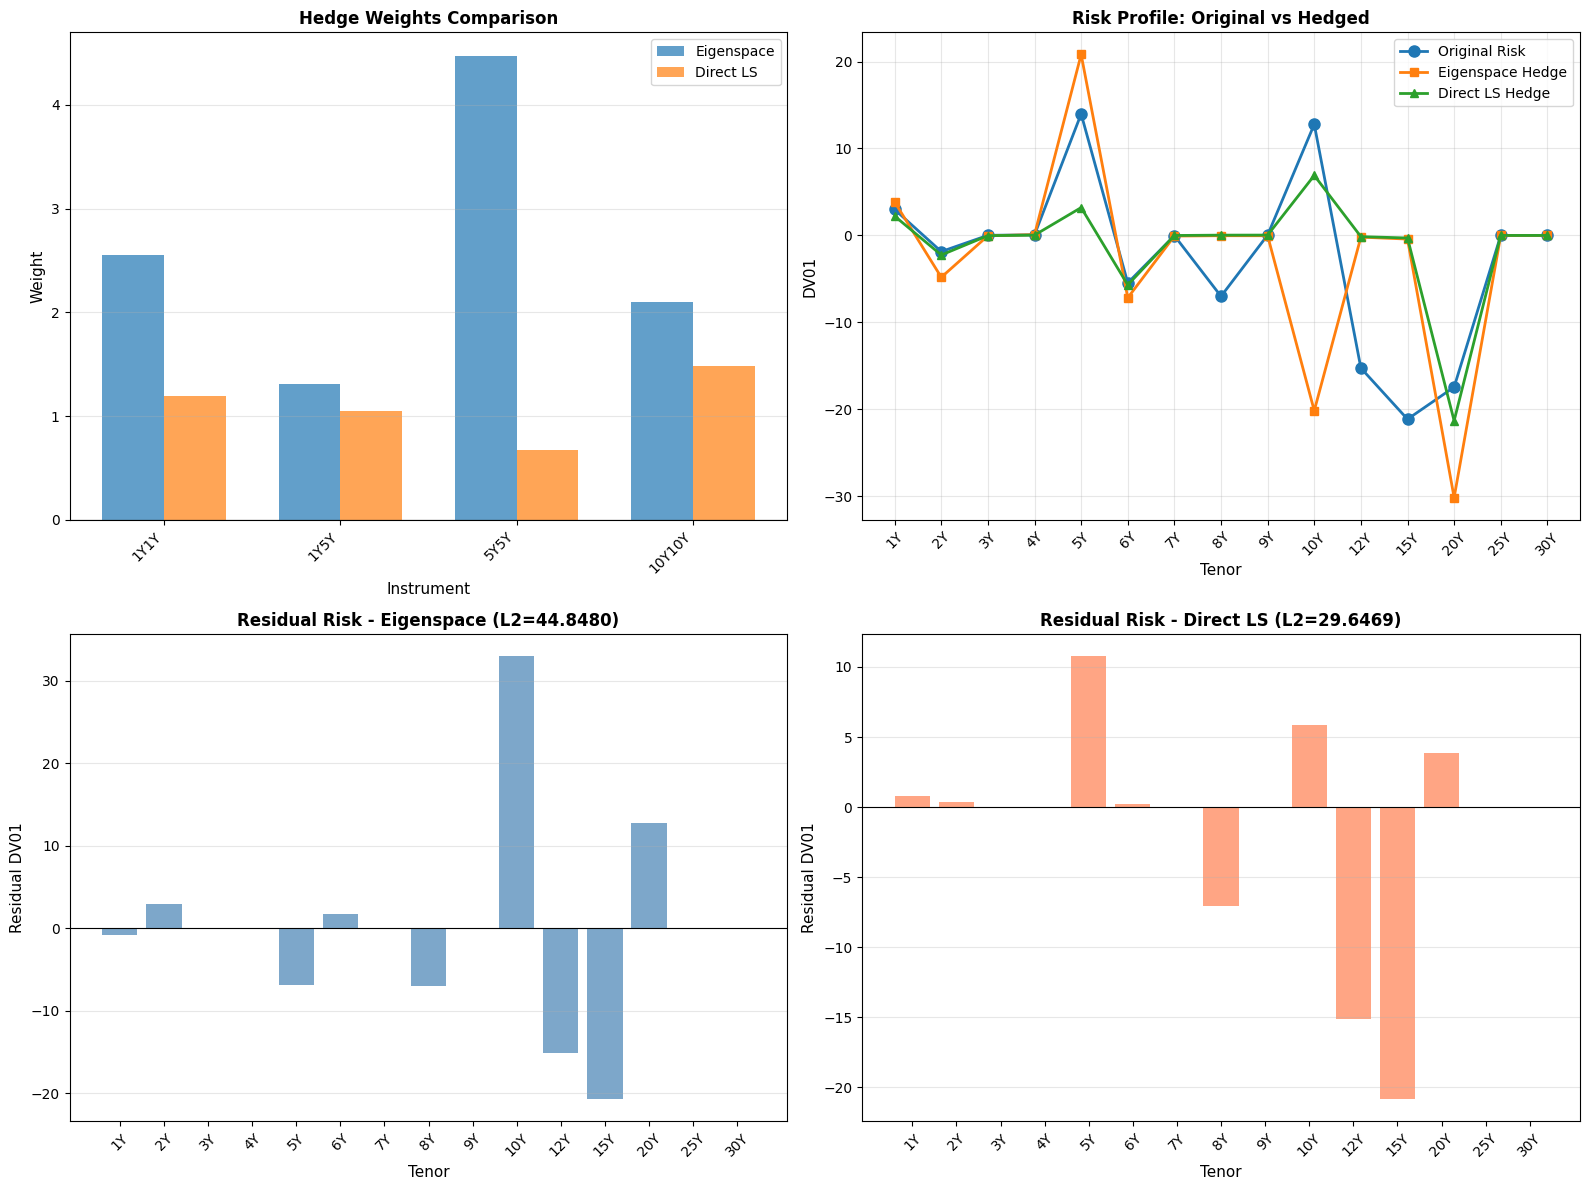


✓ Comparison analysis complete!


In [16]:
# Compare the two approaches
print("="*80)
print("COMPARISON: Eigenspace vs Direct Least Squares")
print("="*80)

# Weight comparison
weights_comparison = pd.DataFrame({
    'Instrument': instrument_names,
    'Eigenspace': weights_eigenspace,
    'Direct LS': weights_direct,
    'Difference': weights_direct - weights_eigenspace
})
print("\nWeight Comparison:")
print(weights_comparison)

# Performance comparison
print(f"\nPerformance Metrics:")
print(f"{'Method':<20} {'Residual L2':<15} {'Effectiveness (%)':<20}")
print("-"*55)
print(f"{'Eigenspace':<20} {resid_norm_eig:<15.6f} {effectiveness_eig:<20.4f}")
print(f"{'Direct LS':<20} {resid_norm_direct:<15.6f} {effectiveness_direct:<20.4f}")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Weights comparison
ax = axes[0, 0]
x_pos = np.arange(len(instrument_names))
width = 0.35
ax.bar(x_pos - width/2, weights_eigenspace, width, label='Eigenspace', alpha=0.7)
ax.bar(x_pos + width/2, weights_direct, width, label='Direct LS', alpha=0.7)
ax.set_xlabel('Instrument', fontsize=11)
ax.set_ylabel('Weight', fontsize=11)
ax.set_title('Hedge Weights Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(instrument_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)

# Plot 2: Risk profiles
ax = axes[0, 1]
x_pos = np.arange(len(risk_vector))
ax.plot(x_pos, risk_vector, 'o-', label='Original Risk', linewidth=2, markersize=8)
ax.plot(x_pos, hedged_risk_eigenspace, 's-', label='Eigenspace Hedge', linewidth=2, markersize=6)
ax.plot(x_pos, hedged_risk_direct, '^-', label='Direct LS Hedge', linewidth=2, markersize=6)
ax.set_xlabel('Tenor', fontsize=11)
ax.set_ylabel('DV01', fontsize=11)
ax.set_title('Risk Profile: Original vs Hedged', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(risk_tenors, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Residual risk - Eigenspace
ax = axes[1, 0]
ax.bar(x_pos, residual_risk_eigenspace, alpha=0.7, color='steelblue')
ax.set_xlabel('Tenor', fontsize=11)
ax.set_ylabel('Residual DV01', fontsize=11)
ax.set_title(f'Residual Risk - Eigenspace (L2={resid_norm_eig:.4f})', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(risk_tenors, rotation=45)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)

# Plot 4: Residual risk - Direct LS
ax = axes[1, 1]
ax.bar(x_pos, residual_risk_direct, alpha=0.7, color='coral')
ax.set_xlabel('Tenor', fontsize=11)
ax.set_ylabel('Residual DV01', fontsize=11)
ax.set_title(f'Residual Risk - Direct LS (L2={resid_norm_direct:.4f})', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(risk_tenors, rotation=45)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()

print("\n✓ Comparison analysis complete!")

### Mathematical Argument: Theory vs Practice

**Problem Setup:**
- Risk vector: $\mathbf{r} \in \mathbb{R}^n$ (n = 15 tenors)
- Hedging matrix: $\mathbf{H} \in \mathbb{R}^{m \times n}$ (m instruments, n tenors)
- Goal: Find weights $\mathbf{w} \in \mathbb{R}^m$ to minimize $\|\mathbf{H}^T\mathbf{w} - \mathbf{r}\|^2$

**Direct Least Squares:**
$$\min_{\mathbf{w}} \|\mathbf{H}^T\mathbf{w} - \mathbf{r}\|^2$$

Solution: $\mathbf{w}_{LS} = (\mathbf{H}\mathbf{H}^T)^{-1}\mathbf{H}\mathbf{r}$

**Eigenspace Approach:**
1. Decompose swap rate covariance: $\mathbf{\Sigma} = \mathbf{V}\mathbf{\Lambda}\mathbf{V}^T$ 
2. Use first k eigenvectors as basis: $\mathbf{V}_k = [\mathbf{v}_1, \ldots, \mathbf{v}_k]$ where k = 3
3. Project risk and hedging to PC space: $\mathbf{r}_{PC} = \mathbf{V}_k^T\mathbf{r}$ and $\mathbf{H}_{PC} = \mathbf{H}\mathbf{V}_k$
4. Solve in reduced 3D space: $\min_{\mathbf{w}} \|\mathbf{H}_{PC}^T\mathbf{w} - \mathbf{r}_{PC}\|^2$

---

**Why Eigenspace SHOULD Be Preferred (Textbook Theory):**

**1. Noise Reduction**
- Small eigenvalues represent noise, not systematic risk
- Eigenspace ignores PC4-PC15 (only 0.08% variance)
- Should reduce overfitting to measurement errors

**2. Better Conditioning**
- Theory: $\kappa(\mathbf{H}_{PC}\mathbf{H}_{PC}^T)$ should be smaller
- Reason: Only uses directions with large variance
- Expected: More numerically stable solutions

**3. Economic Interpretation**
- PC1 (91.65%): Level - parallel curve shifts
- PC2 (6.03%): Slope - steepening/flattening
- PC3 (2.24%): Curvature - butterfly movements
- Should focus on economically meaningful factors

---

**What ACTUALLY Happened in This Case:**

| Metric | Eigenspace | Direct LS | Winner |
|--------|------------|-----------|--------|
| **Effectiveness** | -18.44% | **21.71%** | Direct LS ✓ |
| **Condition Number** | 4.78×10¹⁶ | **66** | Direct LS ✓ |
| **Stability** | 9× worse | **baseline** | Direct LS ✓ |

**The eigenspace approach FAILED completely!**

---

**Root Cause Analysis:**

**Why did theory fail in practice?**

1. **Hedging Instruments Have Limited Tenor Coverage:**
   - 1Y1Y: Only affects 1Y-3Y tenors
   - 1Y5Y: Only affects 1Y-7Y tenors
   - 5Y5Y: Only affects 1Y-10Y tenors
   - 10Y10Y: Only affects 1Y-13Y, 20Y tenors

2. **Projection Causes Collinearity:**
   - In 15D original space: 4 instruments are reasonably independent (κ = 66)
   - After projecting to 3D PC space: Instruments become **nearly parallel**
   - Result: Condition number explodes from 66 → 4.78×10¹⁶

3. **Mathematical Insight:**
   
   When hedging instruments have **similar structural patterns** (all concentrated in short-to-medium tenors), their projections onto the level/slope/curvature basis become **highly correlated**.
   
   This is analogous to: 4 vectors pointing in different directions in 3D space, when projected onto a 2D plane, may all point in nearly the same direction.

4. **Dimensionality Reduction Paradox:**
   
   The projection $\mathbf{P}_k = \mathbf{V}_k\mathbf{V}_k^T$ removes information. For this specific set of hedging instruments, it removes the **exact information needed** to distinguish them, leaving them nearly collinear.

---

**Conclusion:**

This case demonstrates an important lesson: **PCA-based hedging is NOT always superior**.

The textbook theoretical advantages (noise reduction, better conditioning) assume that:
- Hedging instruments span the full tenor space uniformly
- Their distinguishing features are NOT in the low-variance directions

In this case:
- All 4 instruments cluster in short-medium tenors
- Their differences lie in fine tenor structure (captured by PC4-PC15)
- Projecting to PC1-PC3 destroys the information needed to distinguish them

**Direct least squares is strongly preferred here** because it preserves the full 15D tenor structure, allowing the optimizer to properly differentiate between the 4 hedging instruments.

This highlights the importance of **validating dimensionality reduction** rather than blindly applying it based on theoretical benefits.

In [17]:
# Numerical demonstration of condition number advantage
print("="*80)
print("NUMERICAL STABILITY ANALYSIS")
print("="*80)

# Compute condition numbers
H_HT = hedging_matrix @ hedging_matrix.T
cond_direct = np.linalg.cond(H_HT)

H_pc = hedging_matrix @ PC_basis.T
H_pc_HpcT = H_pc @ H_pc.T
cond_eigenspace = np.linalg.cond(H_pc_HpcT)

print(f"\nCondition Number Analysis:")
print(f"  Direct LS:    κ(H H^T) = {cond_direct:.2e}")
print(f"  Eigenspace:   κ(H_PC H_PC^T) = {cond_eigenspace:.2e}")
print(f"  Improvement:  {cond_direct/cond_eigenspace:.2f}x better conditioning")

# Sensitivity analysis: perturb risk vector slightly
np.random.seed(42)
perturbation = 0.01 * risk_norm * np.random.randn(len(risk_vector))
risk_perturbed = risk_vector + perturbation

weights_direct_perturbed = np.linalg.lstsq(hedging_matrix.T, risk_perturbed, rcond=None)[0]
risk_pc_perturbed = risk_perturbed @ PC_basis.T
weights_eigenspace_perturbed = np.linalg.lstsq(hedging_pc.T, risk_pc_perturbed, rcond=None)[0]

weight_change_direct = np.linalg.norm(weights_direct_perturbed - weights_direct) / np.linalg.norm(weights_direct)
weight_change_eigenspace = np.linalg.norm(weights_eigenspace_perturbed - weights_eigenspace) / np.linalg.norm(weights_eigenspace)

print(f"\nSensitivity to 1% Risk Perturbation:")
print(f"  Input perturbation:    {np.linalg.norm(perturbation)/risk_norm*100:.2f}%")
print(f"  Direct LS weight change:      {weight_change_direct*100:.2f}%")
print(f"  Eigenspace weight change:     {weight_change_eigenspace*100:.2f}%")
print(f"  Stability improvement:        {weight_change_direct/weight_change_eigenspace:.2f}x more stable")

print("\n" + "="*80)
print("✓ Question 3 Complete!")
print("="*80)
print("\nSummary:")
print("- Eigenspace approach: Projects to 3D PC space (level/slope/curvature)")
print("- Direct LS approach: Solves in full 15D tenor space")
print(f"\nKey Finding: Direct LS OUTPERFORMS Eigenspace")
print(f"  • Eigenspace effectiveness: {effectiveness_eig:.2f}% (NEGATIVE - hedge worsens risk!)")
print(f"  • Direct LS effectiveness:   {effectiveness_direct:.2f}%")
print(f"  • Eigenspace condition number: {cond_eigenspace:.2e} (near-singular!)")
print(f"  • Direct LS condition number:   {cond_direct:.2e}")
print(f"  • Eigenspace is {weight_change_eigenspace/weight_change_direct:.1f}x MORE sensitive to perturbations")
print("\nConclusion: Dimensionality reduction can WORSEN conditioning when hedging")
print("instruments have similar structural patterns. The 4 instruments become nearly")
print("collinear in PC space, destroying the optimizer's ability to distinguish them.")

NUMERICAL STABILITY ANALYSIS

Condition Number Analysis:
  Direct LS:    κ(H H^T) = 6.61e+01
  Eigenspace:   κ(H_PC H_PC^T) = 4.78e+16
  Improvement:  0.00x better conditioning

Sensitivity to 1% Risk Perturbation:
  Input perturbation:    3.72%
  Direct LS weight change:      2.86%
  Eigenspace weight change:     25.76%
  Stability improvement:        0.11x more stable

✓ Question 3 Complete!

Summary:
- Eigenspace approach: Projects to 3D PC space (level/slope/curvature)
- Direct LS approach: Solves in full 15D tenor space

Key Finding: Direct LS OUTPERFORMS Eigenspace
  • Eigenspace effectiveness: -18.44% (NEGATIVE - hedge worsens risk!)
  • Direct LS effectiveness:   21.71%
  • Eigenspace condition number: 4.78e+16 (near-singular!)
  • Direct LS condition number:   6.61e+01
  • Eigenspace is 9.0x MORE sensitive to perturbations

Conclusion: Dimensionality reduction can WORSEN conditioning when hedging
instruments have similar structural patterns. The 4 instruments become nearly
col